### Psychometric function
Edit the numbers marked `👈` and re-run.

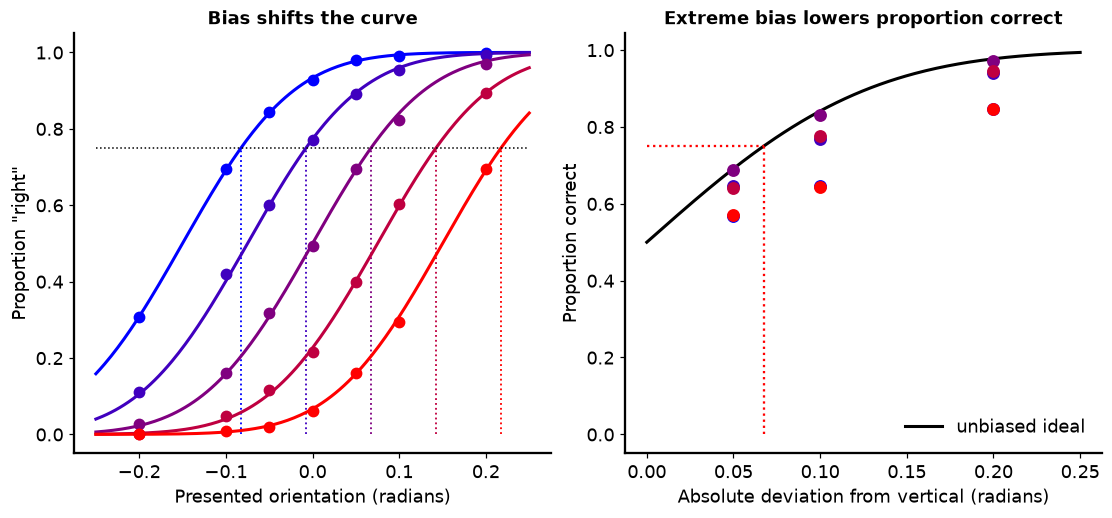

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# How BIAS (criterion) shifts the curve, and how extreme bias hurts proportion correct
signal_strengths = np.array([-0.2,-0.1,-0.05,0,0.05,0.1,0.2])
noise_sd = 0.1
ntrials  = 1000
criteria = np.linspace(-0.15, 0.15, 5)   # 👈 a range of biases

rng = np.random.default_rng()
samples = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd + signal_strengths
pr = np.array([[(samples[:, si] > c).mean() for si in range(signal_strengths.size)] for c in criteria])

colours = np.column_stack([np.linspace(0,1,criteria.size), np.zeros(criteria.size), np.linspace(1,0,criteria.size)])
xs = np.linspace(-0.25, 0.25, 200)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.6), constrained_layout=True)

# left: the biased psychometric functions (slope unchanged, curve shifts)
for ci, c in enumerate(criteria):
    axL.scatter(signal_strengths, pr[ci], 45, color=colours[ci], zorder=3)
    axL.plot(xs, norm.cdf(xs, c, noise_sd), color=colours[ci], lw=2)
    bad = norm.ppf(0.75, c, noise_sd)
    axL.plot([bad, bad], [0, 0.75], color=colours[ci], ls=":", lw=1.2)
axL.plot([-0.25, 0.25], [0.75, 0.75], "k:", lw=1)
axL.set(xlabel="Presented orientation (radians)", ylabel='Proportion "right"', title="Bias shifts the curve")

# right: proportion correct by absolute deviation, per bias, vs the unbiased ideal
abs_devs = np.unique(np.abs(signal_strengths)); abs_devs = abs_devs[abs_devs > 0]
pcorrect = np.full((criteria.size, abs_devs.size), np.nan)
for ci in range(criteria.size):
    for ai, d in enumerate(abs_devs):
        i_neg = np.argmin(np.abs(signal_strengths + d))
        i_pos = np.argmin(np.abs(signal_strengths - d))
        pcorrect[ci, ai] = ((1 - pr[ci, i_neg]) + pr[ci, i_pos]) / 2
for ci in range(criteria.size):
    axR.scatter(abs_devs, pcorrect[ci], 55, color=colours[ci], zorder=3)
xs2 = np.linspace(0, 0.25, 200)
axR.plot(xs2, norm.cdf(xs2, 0, noise_sd), "k", lw=2, label="unbiased ideal")
thr = norm.ppf(0.75, 0, noise_sd)
axR.plot([0, thr], [0.75, 0.75], "r:", lw=1.5); axR.plot([thr, thr], [0, 0.75], "r:", lw=1.5)
axR.set(xlabel="Absolute deviation from vertical (radians)", ylabel="Proportion correct",
        title="Extreme bias lowers proportion correct")
axR.legend(loc="lower right")
plt.show()
